## Memory repertoire diversity across ages and time

In [9]:
import numpy as np
import pyrepseq as prs
import pandas as pd
from scipy.stats import mannwhitneyu

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.style.use("../../project_style.mplstyle")
%config InlineBackend.figure_format = 'retina'

DATA_PATH = "../../data/"

## Richness and diversity in TABLO

In [6]:
tablo = pd.read_csv(DATA_PATH+'tablo/processed/full_table.csv.gz',sep=',')
tablo_memory_blood = tablo[(tablo['annotation_L2'] == 'Memory') & (tablo['origin'] == 'PBMC')]
tablo_memory_tonsil = tablo[(tablo['annotation_L2'] == 'Memory') & (tablo['origin'] == 'Tonsil')]
meta = pd.read_csv(DATA_PATH+'tablo/nonprocessed/10MT_HLA_030123.csv.gz',index_col=0)

In [10]:
metrics = []
for donor, dfg in tablo_memory_blood.groupby('donor'):
    
    clone_sizes = np.array(dfg['full_nt'].value_counts())
    
    pc = prs.pc_n(clone_sizes)
    binned_counts = np.bincount(clone_sizes)
    chao1 = prs.chao1(binned_counts[1:])
    
    metrics.append({"donor": donor, "age":meta.loc[donor]['Age'], 'chao1': chao1, 'Seff': 1/pc})
df_metrics = pd.DataFrame(metrics)
children_metrics = df_metrics[df_metrics['age'] <= 10]
adult_metrics = df_metrics[df_metrics['age'] > 10]
stat_chao1, p_chao1 = mannwhitneyu(children_metrics['chao1'], adult_metrics['chao1'], alternative="two-sided")
stats_Seff, p_Seff =  mannwhitneyu(children_metrics['Seff'], adult_metrics['Seff'], alternative="two-sided")

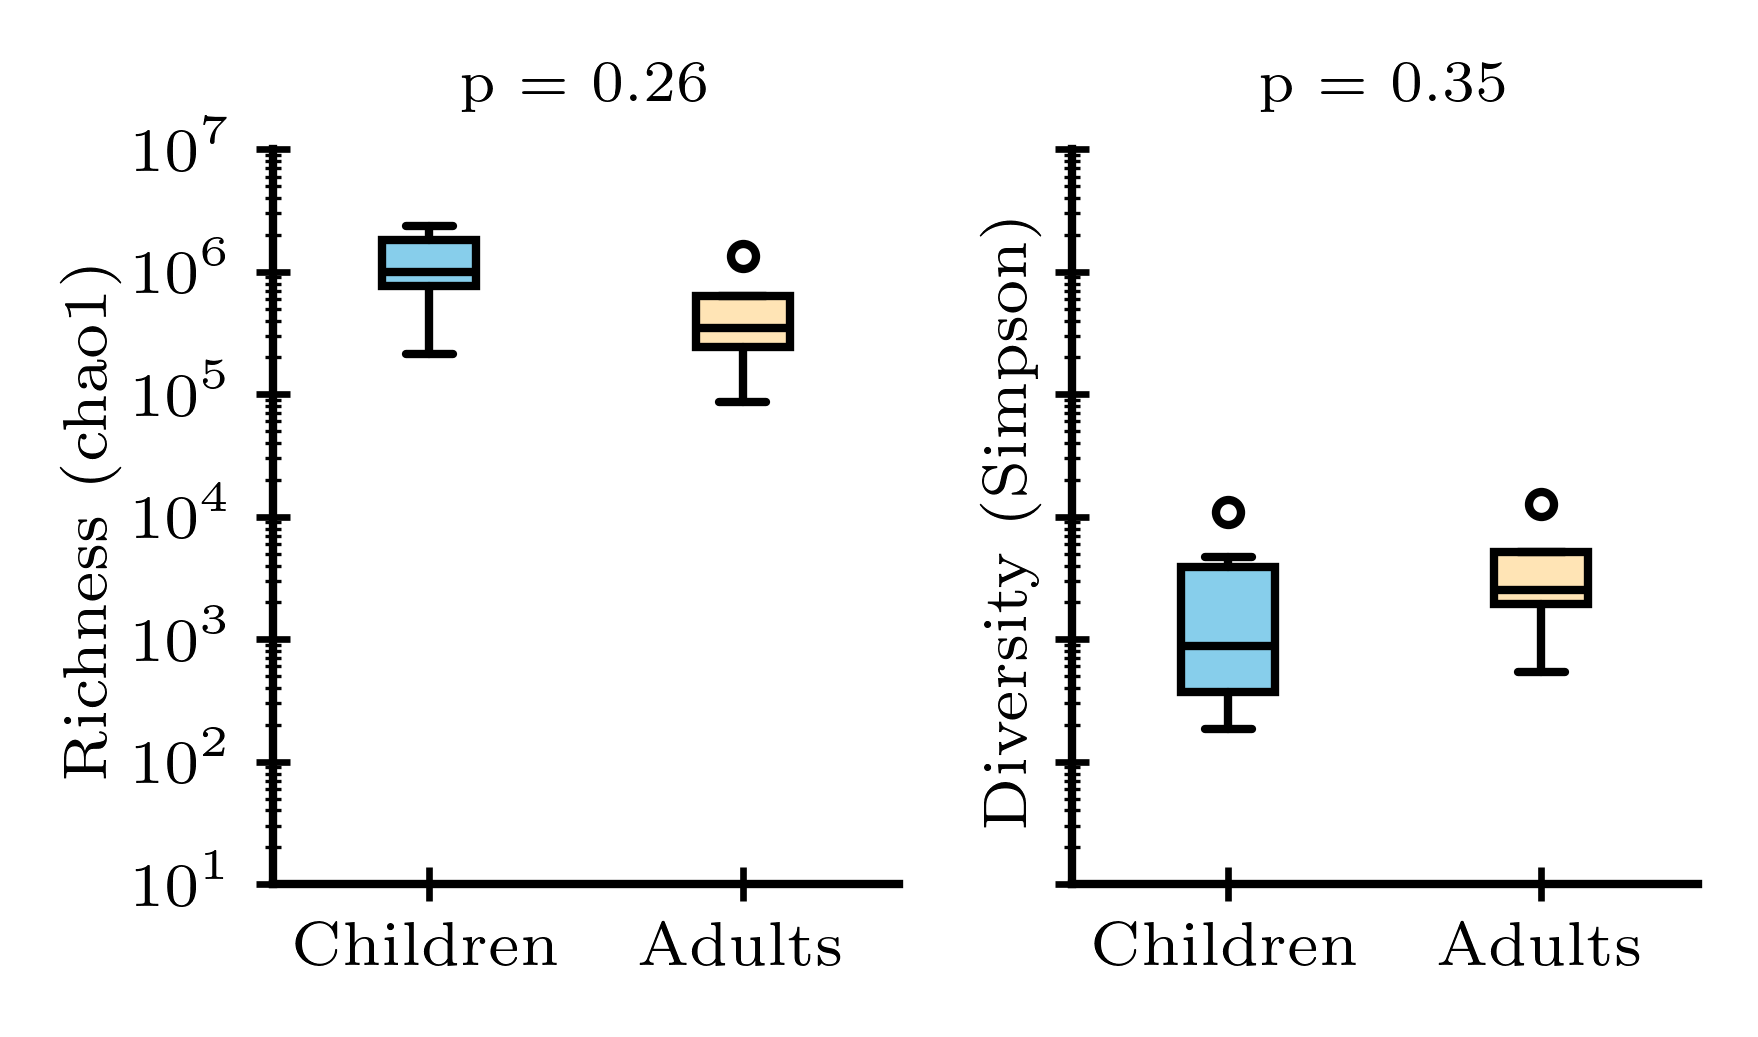

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(3, 1.8), layout='tight', sharey=True)

plots = [("chao1", "Richness (chao1)", p_chao1), ("Seff", "Diversity (Simpson)", p_Seff)]
box_colors = ["skyblue", "lightcoral"]
for i, (metric, label, p_value) in enumerate(plots):
    data = [children_metrics[metric].dropna(), adult_metrics[metric].dropna()]
    bp = ax[i].boxplot(data, tick_labels=["Children", "Adults"], medianprops=dict(color="black"), flierprops=dict(marker="o",markersize=3),  widths=0.3,
                  patch_artist=True)
    
    for patch, color in zip(bp["boxes"], ["skyblue", "moccasin"]):
        patch.set_facecolor(color)

    ax[i].set_title(f"p = {p_value:.2g}", fontsize=7)
    ax[i].set_ylabel(label)
    ax[i].set_yscale('log')
    
ax[0].set_ylim(1e1, 1e7)
ax[0].yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=20))
ax[0].yaxis.set_minor_locator(mticker.LogLocator(base=10,subs=np.arange(2, 10), numticks=100))
    
plt.savefig('../../figures/how_to_maintain_diversity/tablo_diversity.pdf', bbox_inches='tight', dpi=200, transparent=True);